# Color Mask Analysis
Analyze HSV-masked components across reference frames.

## Imports & Setup

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

## Config
Set image directory, HSV bounds, and ignore range here.

In [15]:
image_dir = Path("./pi_data/images/cam0_pattern_test")
output_dir = Path("./pi_data")
output_dir.mkdir(exist_ok=True)

# ── HSV color bounds ───────────────────────────────────────────────────────────
low_hue, up_hue = 125, 150
lower_color = np.array([low_hue, 50, 50])
upper_color = np.array([up_hue, 255, 255])

lower_green = np.array([40, 50, 50])
upper_green = np.array([75, 255, 255])
lower_color, upper_color = lower_green, upper_green

# ── Ignore range (x-coords of camera / artifact region) ───────────────────────
ignore_range = (2000, 2600)

# ── Outside threshold: components with cx <= this are 'outside' paper ─────────
outside_x_threshold = 1250  # adjust after inspecting centroid printout

# ── Row detection ──────────────────────────────────────────────────────────────
row_gap_threshold = 50

## Load Frames

Found 23 frames
pi_data/images/cam0_pattern_test/test_capture_20260224_141504.jpeg → pi_data/images/cam0_pattern_test/test_capture_20260225_080004.jpeg


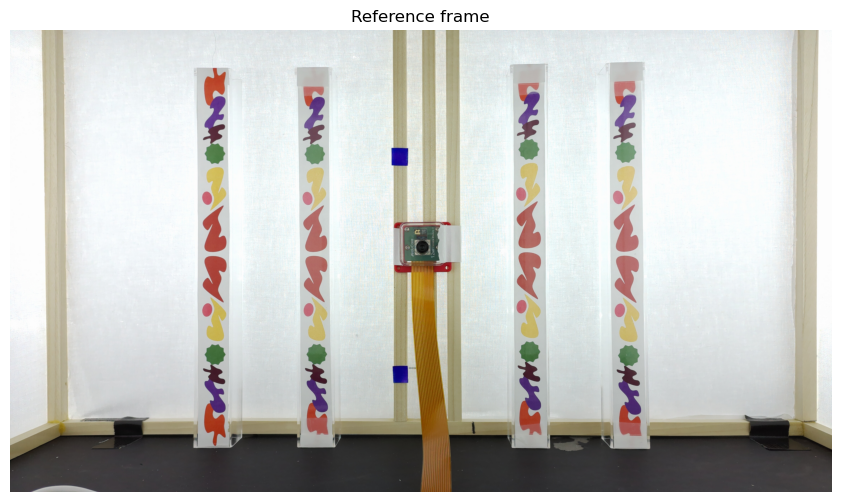

In [16]:
frames = sorted(image_dir.glob("*.jpeg"))
print(f"Found {len(frames)} frames")
print(frames[0], "→", frames[-1])

ref_frame_bgr = cv2.imread(str(frames[0]))
ref_frame_rgb = cv2.cvtColor(ref_frame_bgr, cv2.COLOR_BGR2RGB)
ref_frame_hsv = cv2.cvtColor(ref_frame_bgr, cv2.COLOR_BGR2HSV)

plt.figure(figsize=(14, 6))
plt.imshow(ref_frame_rgb)
plt.title("Reference frame")
plt.axis('off')
plt.show()

## Helper Functions

In [4]:
def build_mask(frame_bgr, lower, upper, ignore_x=None):
    """Build morphologically cleaned HSV mask, optionally zeroing an x-range."""
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    mask = cv2.inRange(frame_hsv, lower, upper)
    if ignore_x is not None:
        mask[:, ignore_x[0]:ignore_x[1]] = 0
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask


def extract_components(mask, frame_bgr, ignore_x=None, min_area=100):
    """
    Returns list of dicts per valid component:
      id, area, cx, cy, bbox, hsv_pixels (Nx3)
    """
    frame_hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
    components = []
    for i in range(1, n_labels):
        x, y, w, h, area = stats[i]
        cx, cy = centroids[i]
        if area < min_area:
            continue
        if ignore_x is not None and ignore_x[0] <= cx <= ignore_x[1]:
            continue
        hsv_pixels = frame_hsv[labels == i]  # shape (N, 3)
        components.append({
            'id': i, 'area': area, 'cx': cx, 'cy': cy,
            'bbox': (x, y, w, h), 'hsv_pixels': hsv_pixels,
        })
    return components


def assign_inside_outside(components, outside_x_threshold):
    """Tag each component as 'outside' (cx <= threshold) or 'inside'."""
    for comp in components:
        comp['location'] = 'outside' if comp['cx'] <= outside_x_threshold else 'inside'
    return components


def group_into_rows(components, row_gap_threshold=50):
    """Group components into horizontal rows by cy proximity, sorted L→R."""
    if not components:
        return []
    sorted_comps = sorted(components, key=lambda c: c['cy'])
    rows, current_row = [], [sorted_comps[0]]
    for comp in sorted_comps[1:]:
        row_mean_cy = np.mean([c['cy'] for c in current_row])
        if abs(comp['cy'] - row_mean_cy) <= row_gap_threshold:
            current_row.append(comp)
        else:
            rows.append(current_row)
            current_row = [comp]
    rows.append(current_row)
    for row in rows:
        row.sort(key=lambda c: c['cx'])
    return rows

## Visualize HSV Threshold Bounds

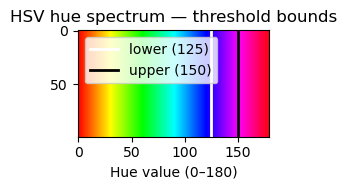

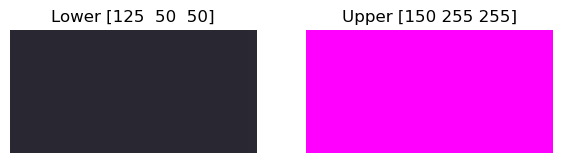

In [5]:
def plot_hue_spectrum(low_hue, up_hue):
    hue_bar = np.zeros((100, 180, 3), dtype=np.uint8)
    for h in range(180):
        hue_bar[:, h] = [h, 255, 255]
    hue_bar_rgb = cv2.cvtColor(cv2.cvtColor(hue_bar, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(12, 2))
    ax.imshow(hue_bar_rgb)
    ax.axvline(x=low_hue, color='white', linewidth=2, label=f'lower ({low_hue})')
    ax.axvline(x=up_hue, color='black', linewidth=2, label=f'upper ({up_hue})')
    ax.set_title("HSV hue spectrum — threshold bounds")
    ax.set_xlabel("Hue value (0–180)")
    ax.legend()
    plt.tight_layout()
    plt.show()
    plt.close()


def plot_color_swatches(lower, upper):
    def make_swatch(hsv):
        s = np.zeros((100, 200, 3), dtype=np.uint8)
        s[:] = hsv
        return cv2.cvtColor(cv2.cvtColor(s, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))
    for ax, swatch, label in zip(axes,
                                  [make_swatch(lower), make_swatch(upper)],
                                  [f"Lower {lower}", f"Upper {upper}"]):
        ax.imshow(swatch)
        ax.set_title(label)
        ax.axis('off')
    plt.show()
    plt.close()


plot_hue_spectrum(low_hue, up_hue)
plot_color_swatches(lower_color, upper_color)

## Build & Inspect Mask

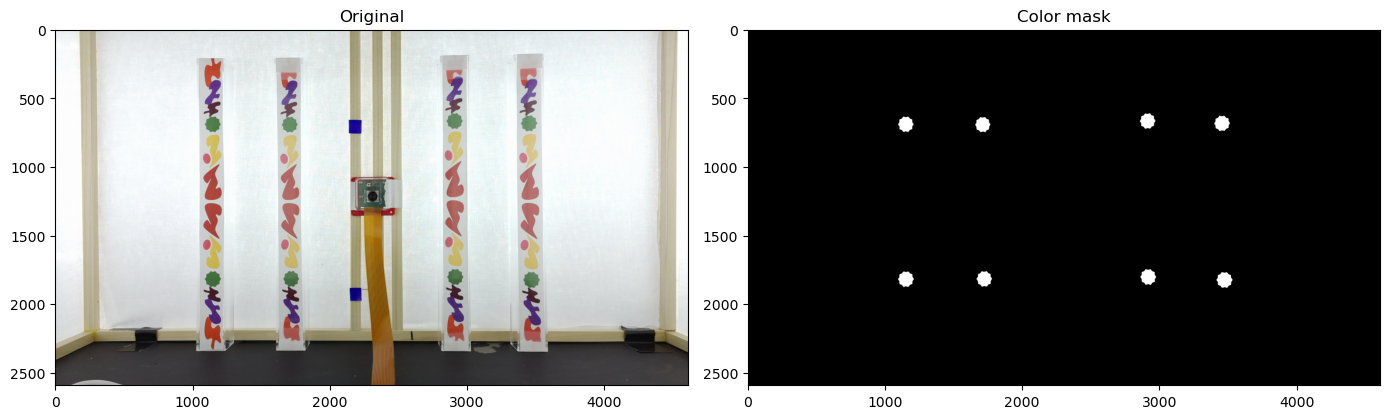

In [17]:
mask = build_mask(ref_frame_bgr, lower_color, upper_color, ignore_x=ignore_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(ref_frame_rgb)
axes[0].set_title("Original")
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Color mask")
plt.tight_layout()
plt.show()

## Extract Components & Assign Inside/Outside

In [18]:
components = extract_components(mask, ref_frame_bgr, ignore_x=ignore_range)
components = assign_inside_outside(components, outside_x_threshold)

print(f"Found {len(components)} valid components")
for c in components:
    print(f"  id={c['id']}  area={c['area']:6d}  cx={c['cx']:7.1f}  cy={c['cy']:7.1f}  [{c['location']}]")

Found 8 valid components
  id=1  area=  9090  cx= 2908.8  cy=  669.7  [inside]
  id=2  area=  9142  cx= 3450.5  cy=  686.4  [inside]
  id=3  area=  9081  cx= 1148.7  cy=  693.2  [outside]
  id=4  area=  8773  cx= 1708.8  cy=  695.7  [inside]
  id=5  area=  9407  cx= 2913.3  cy= 1805.1  [inside]
  id=6  area=  9059  cx= 1719.8  cy= 1819.1  [inside]
  id=7  area=  9281  cx= 1149.3  cy= 1820.9  [outside]
  id=8  area=  9529  cx= 3468.2  cy= 1827.0  [inside]


## Plot: Component Areas by Spatial Row

Saved to pi_data/green_mask_areas.png


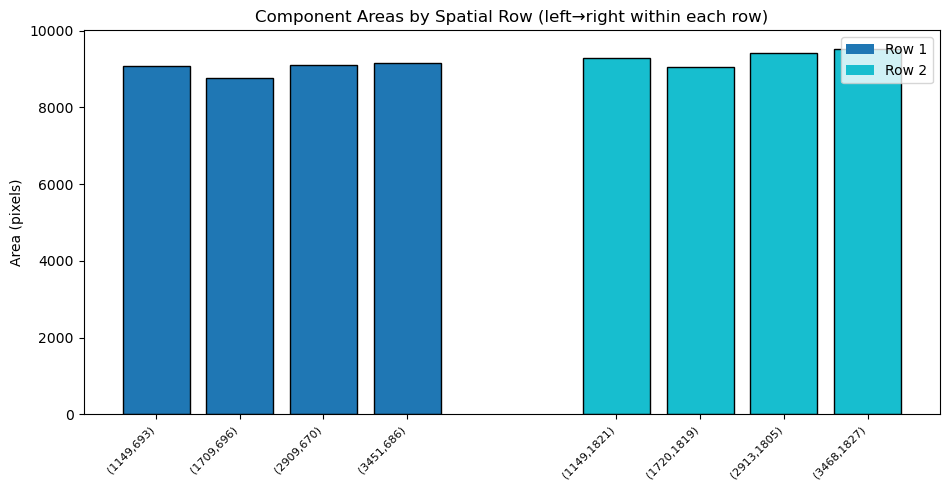

In [19]:
def plot_areas_by_row(components, row_gap_threshold=50, output_path=None):
    rows = group_into_rows(components, row_gap_threshold)
    colors = plt.cm.tab10(np.linspace(0, 1, len(rows)))
    bar_positions, bar_areas, bar_colors, tick_labels = [], [], [], []
    x_pos = 0
    for row_idx, row in enumerate(rows):
        for comp in row:
            bar_positions.append(x_pos)
            bar_areas.append(comp['area'])
            bar_colors.append(colors[row_idx])
            tick_labels.append(f"({comp['cx']:.0f},{comp['cy']:.0f})")
            x_pos += 1
        x_pos += 1.5

    fig, ax = plt.subplots(figsize=(max(8, len(components) * 1.2), 5))
    ax.bar(bar_positions, bar_areas, color=bar_colors, edgecolor='black', width=0.8)
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel("Area (pixels)")
    ax.set_title("Component Areas by Spatial Row (left→right within each row)")
    legend_elements = [Patch(facecolor=colors[i], label=f"Row {i+1}") for i in range(len(rows))]
    ax.legend(handles=legend_elements, loc='upper right')
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {output_path}")
    plt.show()
    plt.close()


plot_areas_by_row(components, row_gap_threshold,
                  output_path=output_dir / "green_mask_areas.png")

## Plot: HSV Violin Plots (Inside vs Outside)

Saved to pi_data/green_hsv_violins.png


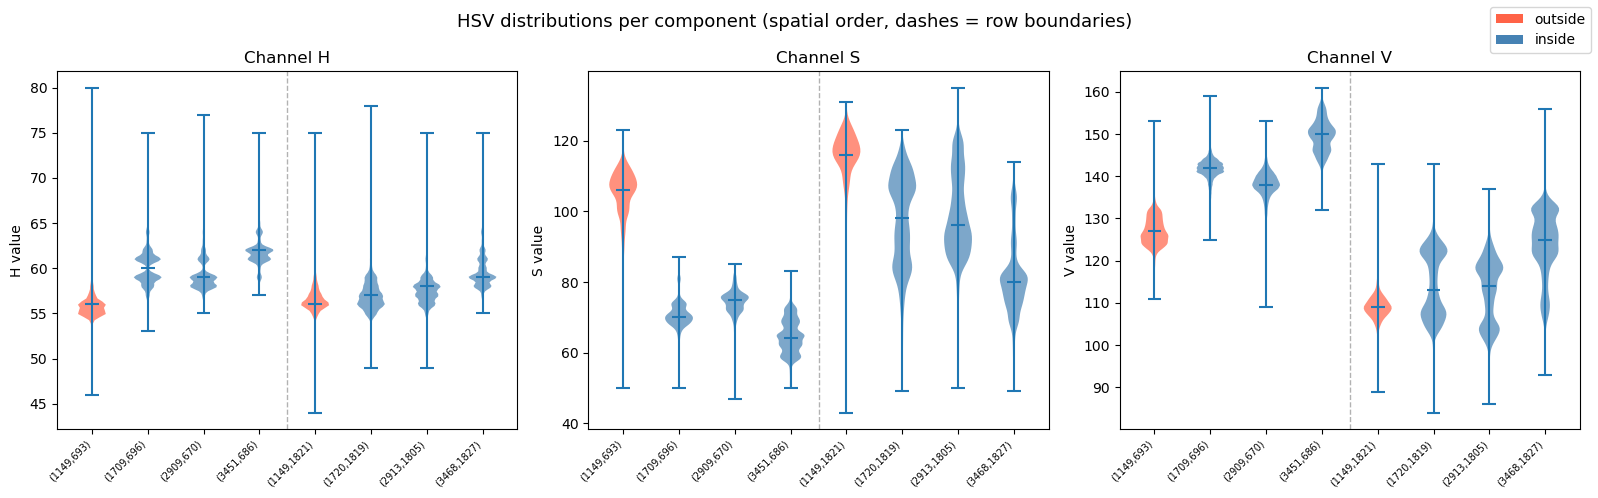

In [20]:
def plot_hsv_violins(components, row_gap_threshold=50, output_path=None):
    channels = ['H', 'S', 'V']
    rows = group_into_rows(components, row_gap_threshold)

    # Build ordered data following spatial layout: row by row, left to right
    ordered = [comp for row in rows for comp in row]

    # Row boundary positions for visual separators
    row_end_positions = []
    pos = 0
    for row in rows:
        pos += len(row)
        row_end_positions.append(pos - 0.5)  # separator after each row

    fig, axes = plt.subplots(1, 3, figsize=(max(16, len(ordered) * 1.2), 5))

    for ax, ch_idx, ch_name in zip(axes, range(3), channels):
        data, labels, colors = [], [], []
        for comp in ordered:
            data.append(comp['hsv_pixels'][:, ch_idx].astype(float))
            labels.append(f"({comp['cx']:.0f},{comp['cy']:.0f})")
            colors.append('tomato' if comp['location'] == 'outside' else 'steelblue')

        parts = ax.violinplot(data, positions=range(len(data)), showmedians=True)
        for pc, color in zip(parts['bodies'], colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)

        # Draw vertical separators between rows
        for sep in row_end_positions[:-1]:  # skip the last one (end of all data)
            ax.axvline(x=sep, color='gray', linewidth=1, linestyle='--', alpha=0.6)

        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
        ax.set_title(f"Channel {ch_name}")
        ax.set_ylabel(f"{ch_name} value")

    fig.legend(handles=[Patch(facecolor='tomato', label='outside'),
                        Patch(facecolor='steelblue', label='inside')],
               loc='upper right')
    fig.suptitle("HSV distributions per component (spatial order, dashes = row boundaries)", fontsize=13)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {output_path}")
    plt.show()
    plt.close()


plot_hsv_violins(components, row_gap_threshold, output_path=output_dir / "green_hsv_violins.png")

## Plot: V Channel Histograms (Spatial Layout)

Saved to pi_data/green_v_histograms.png


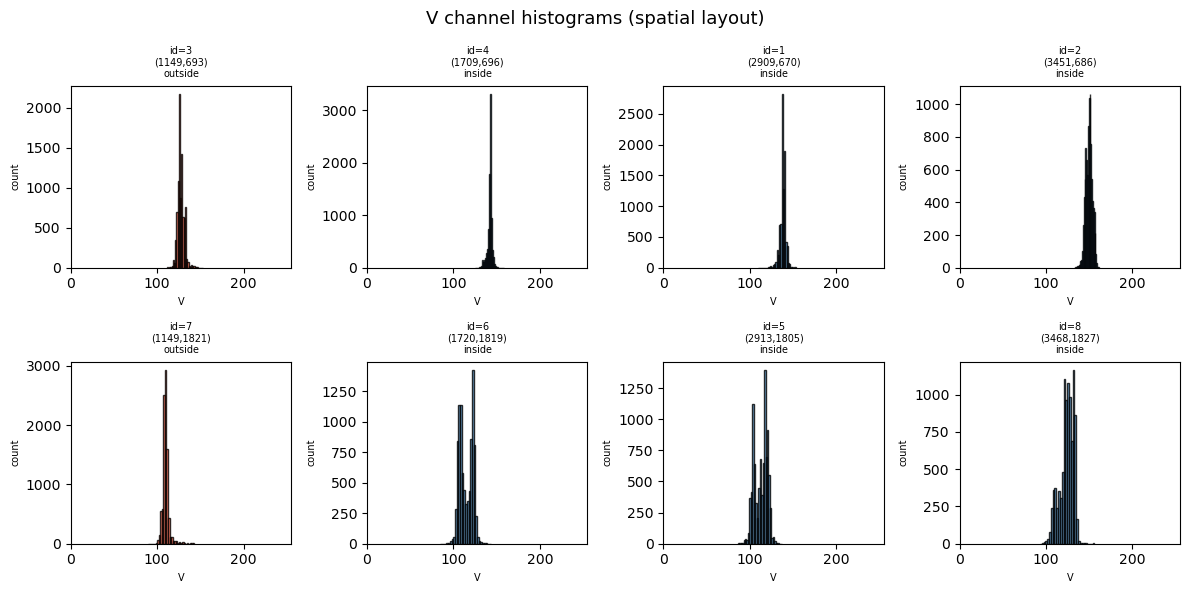

In [21]:
def plot_v_histograms(components, row_gap_threshold=50, output_path=None):
    rows = group_into_rows(components, row_gap_threshold)
    n_rows = len(rows)
    n_cols = max(len(row) for row in rows)

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(3 * n_cols, 3 * n_rows),
                              squeeze=False)
    for r_idx, row in enumerate(rows):
        for c_idx, comp in enumerate(row):
            ax = axes[r_idx][c_idx]
            color = 'tomato' if comp['location'] == 'outside' else 'steelblue'
            ax.hist(comp['hsv_pixels'][:, 2], bins=30, color=color,
                    alpha=0.8, edgecolor='black')
            ax.set_title(f"id={comp['id']}\n({comp['cx']:.0f},{comp['cy']:.0f})\n{comp['location']}",
                         fontsize=7)
            ax.set_xlabel("V", fontsize=7)
            ax.set_ylabel("count", fontsize=7)
            ax.set_xlim(0, 255)
        for c_idx in range(len(row), n_cols):
            axes[r_idx][c_idx].set_visible(False)

    fig.suptitle("V channel histograms (spatial layout)", fontsize=13)
    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved to {output_path}")
    plt.show()
    plt.close()


plot_v_histograms(components, row_gap_threshold,
                  output_path=output_dir / "green_v_histograms.png")